#### 用于可视化数据集不同seeds分布

In [1]:
# visualize the MAMujoco Datasets

import numpy as np
import matplotlib.pyplot as plt

# import gym envs
from gym.spaces import Box, Discrete
from utils.make_env import make_env
from utils.env_wrappers import DummyVecEnv

# env check
try:
    from multiagent_mujoco.mujoco_multi import MujocoMulti
except:
    print ('MujocoMulti not installed')

from bandit import ContinuousBanditEnv

from utils.buffer import ReplayBuffer
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler

import random
import torch
import os
# make parallel MA-Env
def make_parallel_env(env_id, seed, discrete_action):
    def get_env_fn(rank):
        env = make_env(env_id, discrete_action=discrete_action)
        env.seed(seed + rank * 1000)
        np.random.seed(seed + rank * 1000)
        return env
    return DummyVecEnv([get_env_fn(0)])


/home/qiaodan/anaconda3/envs/diffmarl/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

def vis_data(env_id, data_type, seed, dataset_id, legend_label=False, save_fig=False):

    discrete_action = False
    device = f"cuda:{1}"
    rew_scale = 1.0
    dataset_dir = '/home/qiaodan/Code/diffmarl/datasets' + '/' + env_id + '/' + data_type + '/' + 'seed_{}_data'.format(dataset_id)
    # dataset_dir = '/home/qiaodan/Code/diffmarl/datasets/mix_hc/{}/mixed_data'.format(data_type)


    if env_id == 'HalfCheetah-v2':
        nagents = 2
        buffer_length = int(1e6)  # dataset transitions numbers
        episode_length = int(1000)
    elif env_id in ['simple_spread', 'simple_tag', 'simple_world']:
        nagents = 3
        buffer_length = int(1e6)
        episode_length = int(25)

    batch_size = 1000
    use_gpu = True

    ### make env
    if env_id in ['simple_spread', 'simple_tag', 'simple_world']:
        env = make_parallel_env(env_id, seed, discrete_action)
        env_args, env_info = None, None
    elif env_id == "bandit":
        env = ContinuousBanditEnv()
        env_args, env_info = None, None
    else:
        env_args = {"scenario": env_id, "episode_limit": 1000, "agent_conf": '2x3', "agent_obsk": 0,}
        env = MujocoMulti(env_args=env_args)
        env.seed(seed)
        env_info = env.get_env_info()

    # load full offline datasets to buffer
    if env_id in ['simple_spread', 'simple_tag', 'simple_world', 'bandit']:
        replay_buffer = ReplayBuffer(
            buffer_length, nagents,
            [obsp.shape[0] for obsp in env.observation_space],
            [acsp.shape[0] if isinstance(acsp, Box) else acsp.n for acsp in env.action_space], device = device
        )
    else:
        replay_buffer = ReplayBuffer(
            buffer_length, nagents,
            [env_info['obs_shape'] for _ in env.observation_space],
            [acsp.shape[0] for acsp in env.action_space],
            is_mamujoco=True,
            state_dims=[env_info['state_shape'] for _ in env.observation_space], device = device
        )
    replay_buffer.load_batch_data(dataset_dir, rew_scale = rew_scale)

    if np.isinf(replay_buffer.ave_reward):   # 如果变量是 inf, 代表这条轨迹没有 done=True，要进行 scale
        replay_buffer.ave_reward = replay_buffer.sum_reward / (replay_buffer.filled_i/episode_length)
    print('Average_reward:', replay_buffer.ave_reward)

    # sample = replay_buffer.sample(batch_size, to_gpu=use_gpu)


    # replay_buffer.obs_buffs[0].shape, replay_buffer.obs_buffs[0]
    states = replay_buffer.state_buffs[0]
    actions = np.concatenate((replay_buffer.ac_buffs[0], replay_buffer.ac_buffs[1]), axis=1)


    # 将状态降维到2维
    state_pca = PCA(n_components=2)
    states_2d = state_pca.fit_transform(states)

    # 将动作降维到2维
    action_pca = PCA(n_components=2)
    actions_2d = action_pca.fit_transform(actions)

    # 归一化到0-1范围
    scaler = MinMaxScaler()
    actions_2d_normalized = scaler.fit_transform(actions_2d)

    # 分别生成动作的颜色
    action_colors_x = plt.cm.Blues(actions_2d_normalized[:, 0])
    action_colors_y = plt.cm.PuRd(actions_2d_normalized[:, 1])

    # 混合动作颜色
    mixed_colors = (action_colors_x[:, :3] + action_colors_y[:, :3]) / 2


    # 绘制散点图
    fig, ax = plt.subplots(figsize=(8, 6), dpi=300)
    scatter = ax.scatter(states_2d[:, 0], states_2d[:, 1], c=mixed_colors, s=10)
    ax.set_xlim([-50, 50])
    ax.set_ylim([-50, 50])
    ax.set_xlabel('State Dimension 1', fontsize=12)
    ax.set_ylabel('State Dimension 2', fontsize=12)
    ax.set_title('{} Dataset - Seed {}'.format(data_type, dataset_id).title(), fontsize=15)  # 将标题的每个单词首字母大写


    if legend_label:
        # 在主图中插入颜色渐变 bar，放在边框外侧右方
        axins = inset_axes(ax, width="5%", height="85%", loc='right', borderpad=-6)

        # 调整位置，使其位于边框外侧
        axins.set_position([0.9, 0.2, 0.03, 0.7])  

        gradient = np.linspace(0, 1, 256)
        gradient = np.vstack((gradient, gradient))

        # 创建自定义 colormap
        cmap = np.empty((256, 256, 3))
        for i in range(256):
            for j in range(256):
                blue = np.array(plt.cm.Blues(gradient[0, i])[:3])
                red = np.array(plt.cm.PuRd(gradient[0, j])[:3])
                cmap[i, j, :] = (blue + red) / 2

        axins.imshow(cmap, aspect='auto', extent=[0, 1, 0, 1])
        axins.set_title('Joint Actions', fontsize=12)
        axins.set_xlabel('Act. Dim. 1', fontsize=12)
        axins.set_ylabel('Act. Dim. 2', fontsize=12)
        axins.xaxis.set_label_position('top')
        axins.xaxis.set_ticks_position('top')
        axins.yaxis.set_ticks_position('left')
        axins.tick_params(axis='both', which='major', labelsize=6)
    

    
    save_dir = '/home/qiaodan/Code/diffmarl/results/plot/Abla3'
    if save_fig:
        os.makedirs(save_dir, exist_ok=True)  # 创建目录，如果已存在则不报错
        # 保存图形，指定文件名
        plt.savefig(os.path.join(save_dir, '{}_seed{}.png'.format(data_type, dataset_id)), dpi=200, bbox_inches='tight')  # 可以根据需要更改文件名和格式
    else:
        plt.show()

    plt.close(fig)  # 关闭图形以释放内存


/home/qiaodan/anaconda3/envs/diffmarl/lib/python3.9/site-packages/gym/envs/registration.py:14: PkgResourcesDeprecationWarning: Parameters to load are deprecated.  Call .resolve and .require separately.
  result = entry_point.load(False)


WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
loading batch data from /home/qiaodan/Code/diffmarl/datasets/HalfCheetah-v2/expert/seed_0_data...
Average_reward: 3338.688488713757


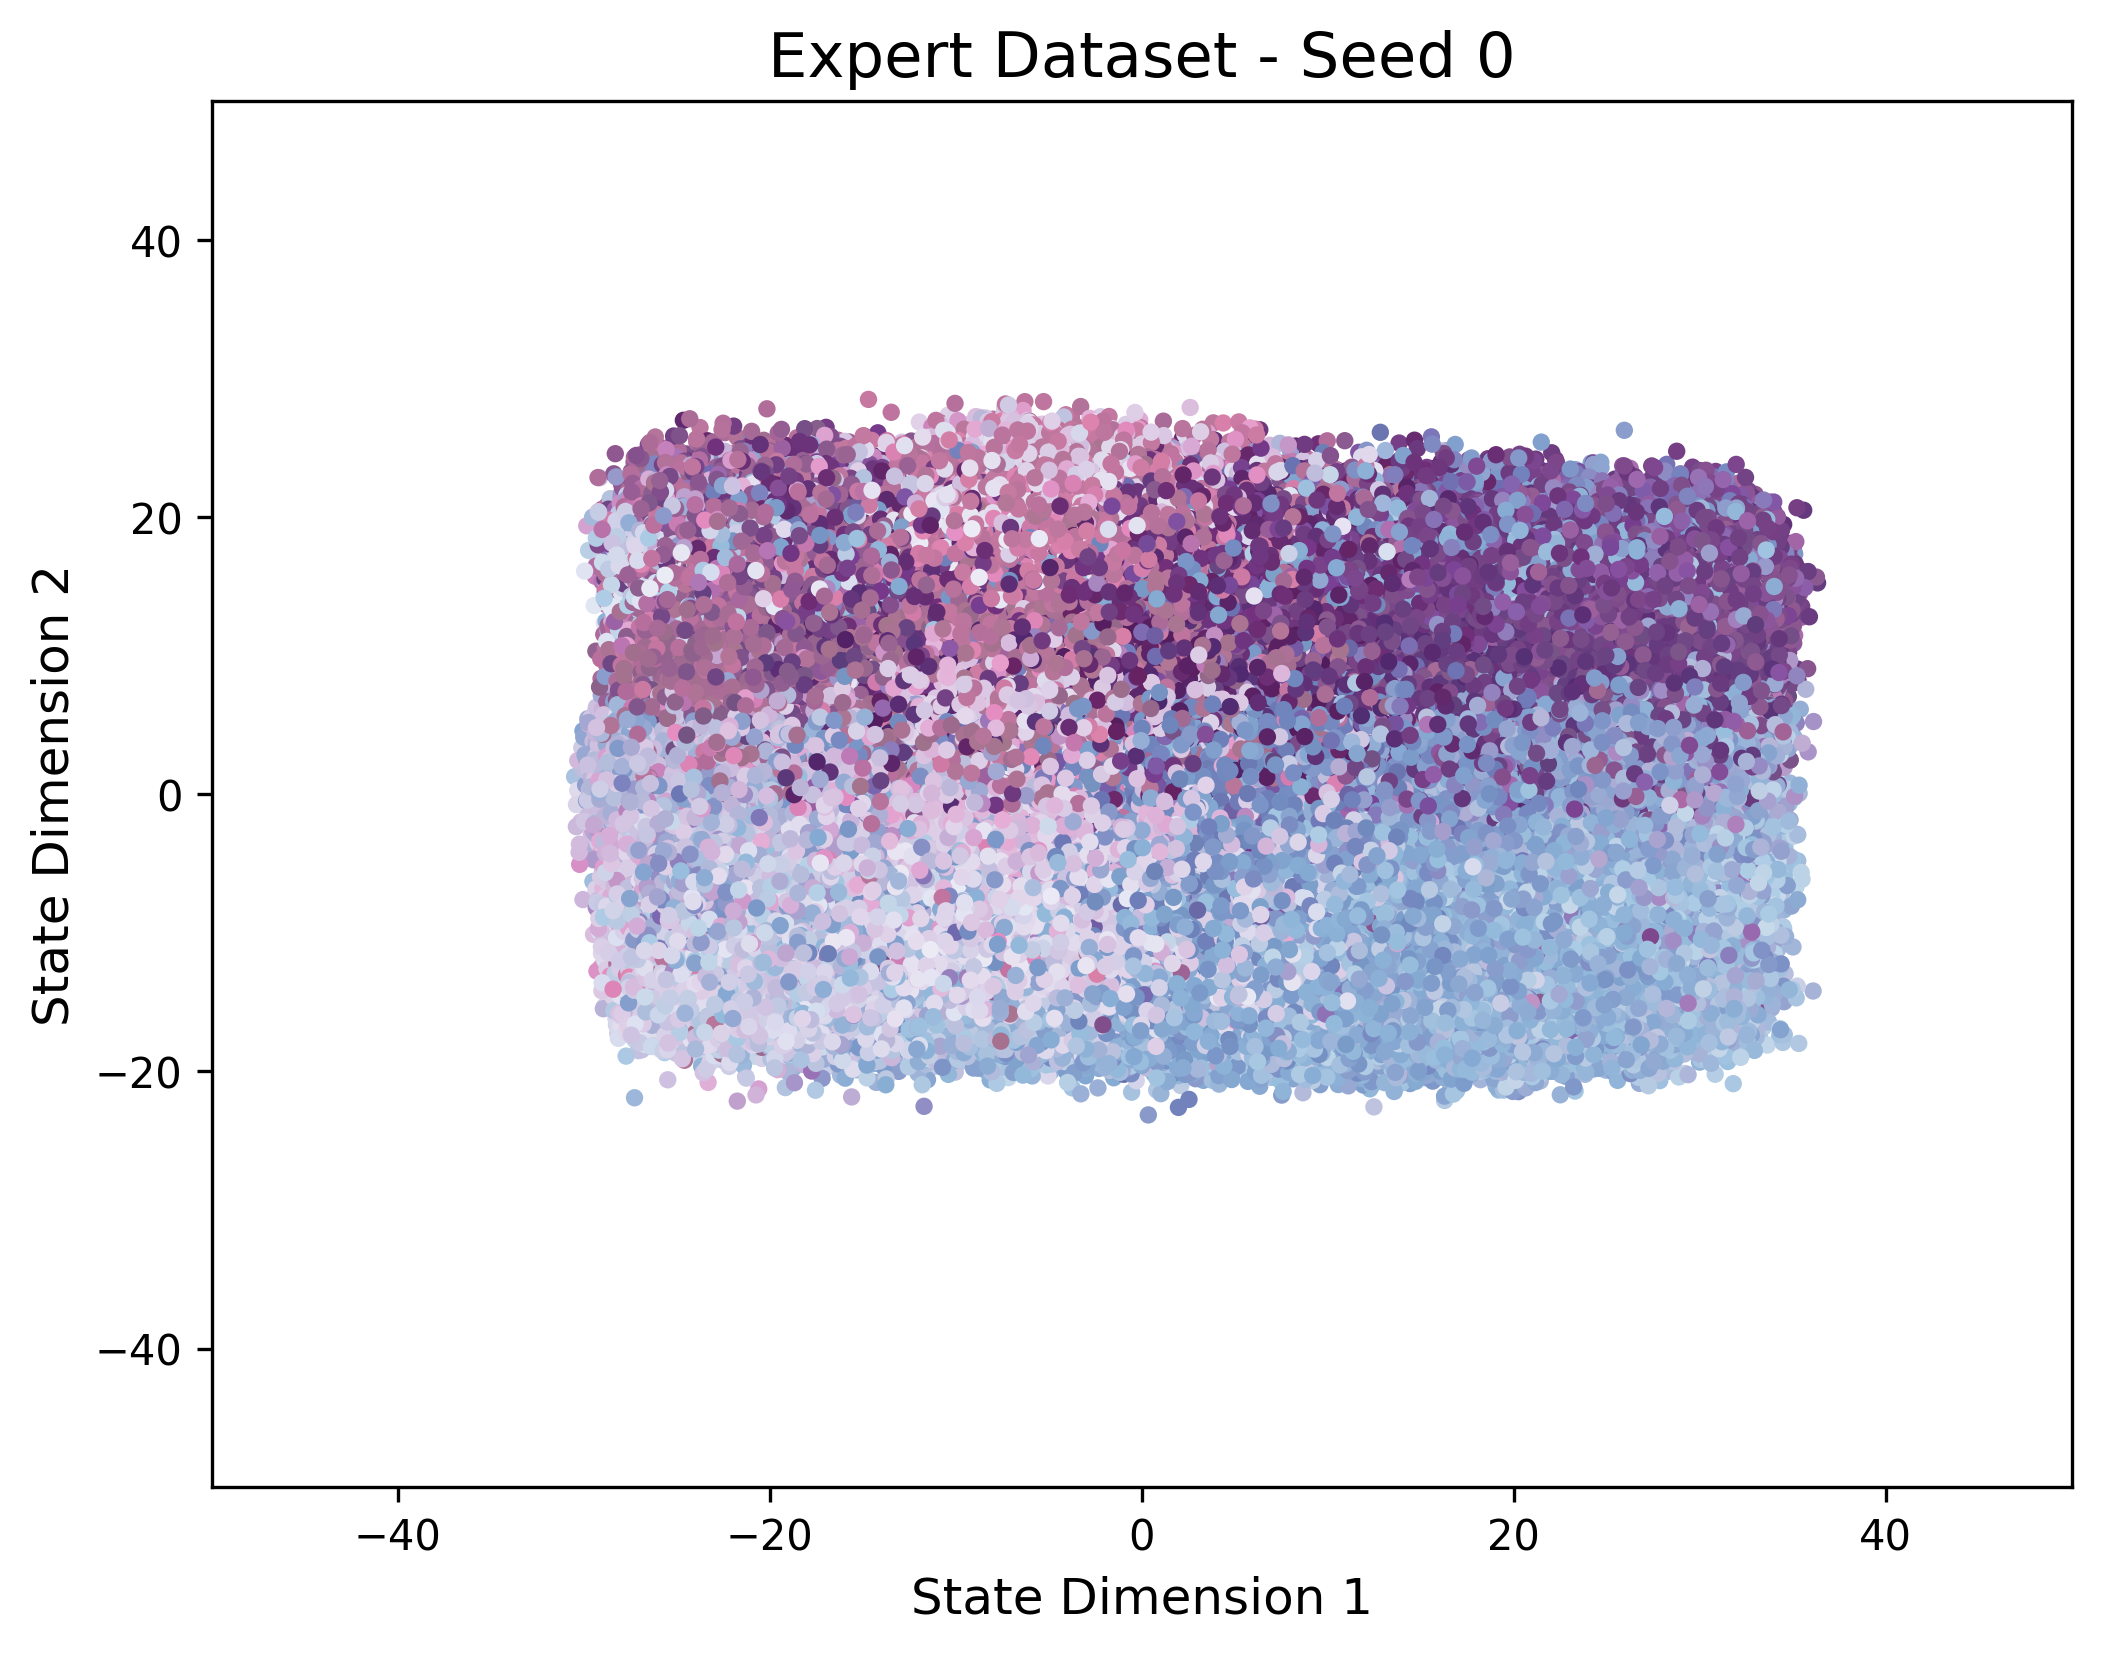

In [7]:
# dataset params
env_id = 'HalfCheetah-v2'  # MPE
data_type = 'expert'  # random medium
dataset_id = 0  # 1 2 3 4
seed = 42

vis_data(env_id, data_type, seed, dataset_id)



In [9]:
type_list = ['expert', 'medium', 'medium-replay'] 
ids = [0, 1, 2, 3, 4]

for type in type_list:
    for id in ids:
        vis_data(env_id, type, 42, id, save_fig=True)

/home/qiaodan/anaconda3/envs/diffmarl/lib/python3.9/site-packages/gym/envs/registration.py:14: PkgResourcesDeprecationWarning: Parameters to load are deprecated.  Call .resolve and .require separately.
  result = entry_point.load(False)


WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
loading batch data from /home/qiaodan/Code/diffmarl/datasets/HalfCheetah-v2/expert/seed_0_data...
Average_reward: 3338.688488713757


/home/qiaodan/anaconda3/envs/diffmarl/lib/python3.9/site-packages/gym/envs/registration.py:14: PkgResourcesDeprecationWarning: Parameters to load are deprecated.  Call .resolve and .require separately.
  result = entry_point.load(False)


WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
loading batch data from /home/qiaodan/Code/diffmarl/datasets/HalfCheetah-v2/expert/seed_1_data...
Average_reward: 3599.979033156354


/home/qiaodan/anaconda3/envs/diffmarl/lib/python3.9/site-packages/gym/envs/registration.py:14: PkgResourcesDeprecationWarning: Parameters to load are deprecated.  Call .resolve and .require separately.
  result = entry_point.load(False)


...

WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
loading batch data from /home/qiaodan/Code/diffmarl/datasets/HalfCheetah-v2/medium-replay/seed_2_data...
Average_reward: 400.0421849664508


/home/qiaodan/anaconda3/envs/diffmarl/lib/python3.9/site-packages/gym/envs/registration.py:14: PkgResourcesDeprecationWarning: Parameters to load are deprecated.  Call .resolve and .require separately.
  result = entry_point.load(False)


WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
loading batch data from /home/qiaodan/Code/diffmarl/datasets/HalfCheetah-v2/medium-replay/seed_3_data...
Average_reward: 502.8021621813886


/home/qiaodan/anaconda3/envs/diffmarl/lib/python3.9/site-packages/gym/envs/registration.py:14: PkgResourcesDeprecationWarning: Parameters to load are deprecated.  Call .resolve and .require separately.
  result = entry_point.load(False)


WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
loading batch data from /home/qiaodan/Code/diffmarl/datasets/HalfCheetah-v2/medium-replay/seed_4_data...
Average_reward: 525.9739585127696


In [12]:
type_list = ['random'] 
ids = [0, 1, 2, 3, 4]

for type in type_list:
    for id in ids:
        vis_data(env_id, type, 42, id, legend_label=True, save_fig=True)

/home/qiaodan/anaconda3/envs/diffmarl/lib/python3.9/site-packages/gym/envs/registration.py:14: PkgResourcesDeprecationWarning: Parameters to load are deprecated.  Call .resolve and .require separately.
  result = entry_point.load(False)


WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
loading batch data from /home/qiaodan/Code/diffmarl/datasets/HalfCheetah-v2/random/seed_0_data...
Average_reward: -282.8917055694527


/home/qiaodan/anaconda3/envs/diffmarl/lib/python3.9/site-packages/gym/envs/registration.py:14: PkgResourcesDeprecationWarning: Parameters to load are deprecated.  Call .resolve and .require separately.
  result = entry_point.load(False)


WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
loading batch data from /home/qiaodan/Code/diffmarl/datasets/HalfCheetah-v2/random/seed_1_data...
Average_reward: -284.73725725585234


/home/qiaodan/anaconda3/envs/diffmarl/lib/python3.9/site-packages/gym/envs/registration.py:14: PkgResourcesDeprecationWarning: Parameters to load are deprecated.  Call .resolve and .require separately.
  result = entry_point.load(False)


...

/home/qiaodan/anaconda3/envs/diffmarl/lib/python3.9/site-packages/gym/envs/registration.py:14: PkgResourcesDeprecationWarning: Parameters to load are deprecated.  Call .resolve and .require separately.
  result = entry_point.load(False)


WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
loading batch data from /home/qiaodan/Code/diffmarl/datasets/HalfCheetah-v2/random/seed_3_data...
Average_reward: -284.7172576497628


/home/qiaodan/anaconda3/envs/diffmarl/lib/python3.9/site-packages/gym/envs/registration.py:14: PkgResourcesDeprecationWarning: Parameters to load are deprecated.  Call .resolve and .require separately.
  result = entry_point.load(False)


WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.
loading batch data from /home/qiaodan/Code/diffmarl/datasets/HalfCheetah-v2/random/seed_4_data...
Average_reward: -284.0695368713673


: 